
# Лабораторная работа № 6

## Анализ текстов научных статей

Решается задача **многоклассовой классификации англоязычных научных аннотаций**. Исходный датасет `scientific_articles.csv` не содержит готовой целевой переменной, поэтому для обучения с учителем используется **слабая разметка**: класс статьи назначается по тематическим словарям только в тех случаях, когда тема определяется однозначно.

Особенности постановки:
- датасет большой, поэтому он загружается **по частям**, а не целиком;
- сравниваются разные варианты предобработки, нормализации, фильтрации, POS-фильтрации, формирования n-грамм и векторизации;
- итогом является таблица экспериментов и выбор лучшей конфигурации.

Проверяемые факторы:
1. метод предобработки текста;
2. влияние выделения частей речи;
3. метод нормализации;
4. метод фильтрации;
5. влияние n-грамм;
6. тип индексирования: `Bag of Words` и `TF-IDF`;
7. выбор модели машинного обучения.



## Импорт библиотек и подготовка ресурсов


In [24]:

import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import nltk
from nltk import pos_tag
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


In [25]:

NLTK_RESOURCES = {
    "corpora/stopwords": "stopwords",
    "taggers/averaged_perceptron_tagger_eng": "averaged_perceptron_tagger_eng",
    "corpora/wordnet": "wordnet",
    "corpora/omw-1.4": "omw-1.4",
}


def ensure_nltk_resource(resource_path: str, download_name: str) -> bool:
    try:
        nltk.data.find(resource_path)
        return True
    except LookupError:
        try:
            return bool(nltk.download(download_name, quiet=True))
        except Exception:
            return False


resource_status = {
    path: ensure_nltk_resource(path, package)
    for path, package in NLTK_RESOURCES.items()
}

HAS_POS = resource_status["taggers/averaged_perceptron_tagger_eng"]
HAS_WORDNET = resource_status["corpora/wordnet"] and resource_status["corpora/omw-1.4"]

resource_status


{'corpora/stopwords': True,
 'taggers/averaged_perceptron_tagger_eng': True,
 'corpora/wordnet': True,
 'corpora/omw-1.4': True}


## Загрузка части датасета


In [26]:
from google.colab import drive
drive.mount('/content/drive')

file_path = "drive/MyDrive/scientific_articles.csv"

DATA_PATH = file_path
MAX_ROWS_TO_READ = 30000
CHUNK_SIZE = 5000
SAMPLE_PER_CLASS = 350


def load_partial_dataset(path: Path, max_rows: int, chunksize: int) -> pd.DataFrame:
    frames = []
    rows_loaded = 0

    for chunk in pd.read_csv(path, usecols=["title", "abstract"], chunksize=chunksize):
        chunk = chunk.dropna(subset=["title", "abstract"]).copy()
        frames.append(chunk)
        rows_loaded += len(chunk)
        if rows_loaded >= max_rows:
            break

    df = pd.concat(frames, ignore_index=True)
    return df.iloc[:max_rows].copy()


df_raw = load_partial_dataset(DATA_PATH, MAX_ROWS_TO_READ, CHUNK_SIZE)
df_raw["text"] = (df_raw["title"].str.strip() + " " + df_raw["abstract"].str.strip()).str.replace(r"\s+", " ", regex=True)

print(f"Загружено строк: {len(df_raw):,}")
df_raw.head(3)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Загружено строк: 30,000


,title,abstract,text
0,Novel carbon material with potential application in lead-acid battery technology,"AbstractLead-acid batteries (LABs) are one of the most important energy storage systems, widely used in automotive, industrial, and backup applications. However, lead-acid batt...","Novel carbon material with potential application in lead-acid battery technology AbstractLead-acid batteries (LABs) are one of the most important energy storage systems, widely..."
1,"Specific conductivities of tetraalkylammonium bis(oxalato)borates in acetonitrile, dimethyl sulfoxide, and propylene carbonate",AbstractSearching for environmentally friendly salts and solvents for electrical double-layer capacitors widely employed in energy storage for fast power delivery is now an imp...,"Specific conductivities of tetraalkylammonium bis(oxalato)borates in acetonitrile, dimethyl sulfoxide, and propylene carbonate AbstractSearching for environmentally friendly sa..."
2,Development of electrochemical sensor for quantification of organophosphates in soil samples,AbstractThis study presents the development of nanohybrid-based working electrodes. Developed electrodes were utilized for the electrochemical detection of organophosphates ext...,Development of electrochemical sensor for quantification of organophosphates in soil samples AbstractThis study presents the development of nanohybrid-based working electrodes....


|
## Формирование целевой переменной

Так как в исходном наборе нет столбца с классами, создадим слабую разметку. Для каждой темы задан словарь характерных терминов. Статья попадает в выборку только тогда, когда найдено совпадение ровно с одной тематикой. Это уменьшает шум в разметке и делает постановку задачи обучения с учителем корректнее.


In [27]:

KEYWORDS = {
    "energy": {
        "battery", "energy", "electrode", "electrolyte", "capacitor",
        "photovoltaic", "solar", "supercapacitor", "fuel cell"
    },
    "chemistry": {
        "chemical", "reaction", "synthesis", "catalyst", "compound",
        "molecule", "polymerization", "spectroscopy", "chromatography"
    },
    "materials": {
        "material", "carbon", "alloy", "composite", "ceramic",
        "nanotube", "film", "membrane", "coating", "nanoparticle"
    },
    "ai": {
        "algorithm", "learning", "neural", "classification", "prediction",
        "optimization", "machine learning", "deep learning", "computer vision"
    },
}


def assign_weak_label(text: str) -> str | None:
    text = text.lower()
    scores = {
        label: sum(keyword in text for keyword in keywords)
        for label, keywords in KEYWORDS.items()
    }
    positive_scores = {label: score for label, score in scores.items() if score > 0}

    if len(positive_scores) != 1:
        return None

    return next(iter(positive_scores))


df_raw["label"] = df_raw["text"].map(assign_weak_label)
df_labeled = df_raw.dropna(subset=["label"]).copy()

label_stats = df_labeled["label"].value_counts().rename_axis("label").reset_index(name="count")
label_stats


,label,count
0,chemistry,3992
1,materials,2076
2,ai,1718
3,energy,1437


In [28]:

min_class_size = df_labeled["label"].value_counts().min()
effective_sample_size = min(SAMPLE_PER_CLASS, min_class_size)

df = (
    df_labeled.groupby("label", group_keys=False)
    .apply(lambda group: group.sample(effective_sample_size, random_state=RANDOM_STATE))
    .reset_index(drop=True)
)

df["text_len"] = df["text"].str.len()
df["token_len"] = df["text"].str.split().str.len()

print(f"Итоговый размер рабочей выборки: {len(df):,}")
print(f"Документов на класс: {effective_sample_size}")
display(df["label"].value_counts())
display(df[["label", "title", "token_len"]].head(8))


Итоговый размер рабочей выборки: 1,400
Документов на класс: 350


,count
label,
ai,350
chemistry,350
energy,350
materials,350


,label,title,token_len
0,ai,Method for taking into account the shift parameter in the deconvolution of the depth composition distribution of semiconductor structures from SIMS depth profiles,165
1,ai,Birational reparameterizations of surfaces,77
2,ai,Scientific visualization: From data to insight,94
3,ai,Classroom,55
4,ai,Satellite Imagery Super-Resolution Using Squeeze-and-Excitation-Based GAN,226
5,ai,Flow Reconstruction Around a Surface-Mounted Prism from Sparse Velocity and/or Scalar Measurements Using a Combination of POD and a Data-Driven Estimator,218
6,ai,Five-year mortality trends associated with sleep disorders in South Korea: a population-based cohort study,255
7,ai,FPGA-based Inference Parallelization for Onboard RL-based Routing in Dynamic LEO Satellite Networks,151


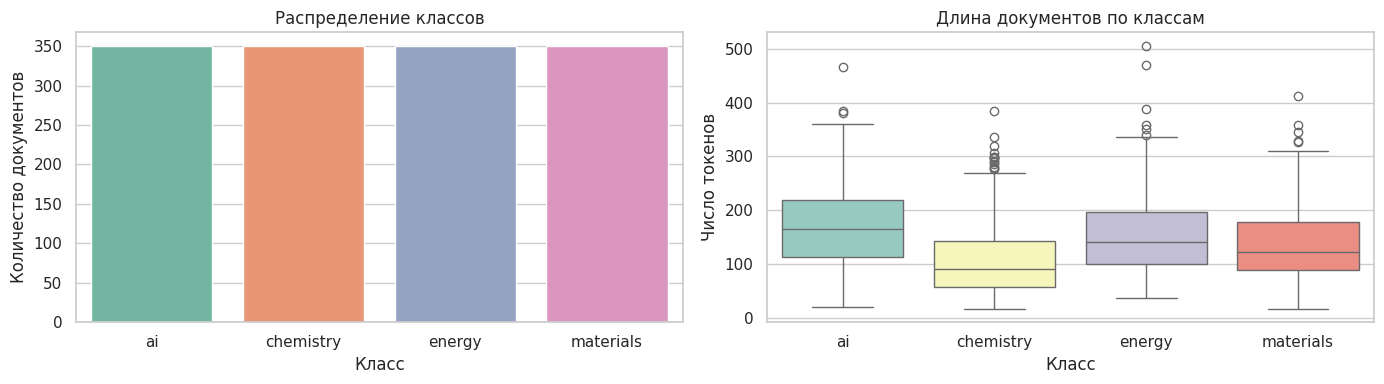

In [29]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(data=df, x="label", order=sorted(df["label"].unique()), ax=axes[0], palette="Set2")
axes[0].set_title("Распределение классов")
axes[0].set_xlabel("Класс")
axes[0].set_ylabel("Количество документов")

sns.boxplot(data=df, x="label", y="token_len", ax=axes[1], palette="Set3")
axes[1].set_title("Длина документов по классам")
axes[1].set_xlabel("Класс")
axes[1].set_ylabel("Число токенов")

plt.tight_layout()
plt.show()



## Предобработка, нормализация и фильтрация

Проверяются следующие варианты:
- предобработка: минимальная и очищающая;
- нормализация: без нормализации, `Porter`, `Snowball`, лемматизация;
- фильтрация: без фильтрации, удаление стоп-слов, удаление стоп-слов и коротких токенов;
- POS-фильтрация: сохранение только содержательных частей речи.


In [30]:

STOP_WORDS = set(stopwords.words("english"))
PORTER = PorterStemmer()
SNOWBALL = SnowballStemmer("english")
LEMMATIZER = WordNetLemmatizer()
TOKEN_RE = re.compile(r"[A-Za-z]+")

WORDNET_POS_MAP = {
    "J": "a",
    "N": "n",
    "R": "r",
    "V": "v",
}

CONTENT_POS_TAGS = {
    "NN", "NNS", "NNP", "NNPS",
    "JJ", "JJR", "JJS",
    "VB", "VBD", "VBG", "VBN", "VBP", "VBZ",
}


def preprocess_text(text: str, mode: str = "clean") -> str:
    text = text.replace("\n", " ").replace("\t", " ")

    if mode == "minimal":
        text = text.lower()
        text = re.sub(r"\s+", " ", text)
        return text.strip()

    if mode == "clean":
        text = text.lower()
        text = re.sub(r"\d+", " ", text)
        text = re.sub(r"[^a-z\s]", " ", text)
        text = re.sub(r"\s+", " ", text)
        return text.strip()

    raise ValueError(f"Неизвестный режим предобработки: {mode}")


def tokenize_text(text: str) -> list[str]:
    return TOKEN_RE.findall(text)


def filter_tokens(tokens: list[str], mode: str = "none") -> list[str]:
    if mode == "none":
        return tokens
    if mode == "stop":
        return [token for token in tokens if token not in STOP_WORDS]
    if mode == "stop_short":
        return [token for token in tokens if token not in STOP_WORDS and len(token) >= 3]
    raise ValueError(f"Неизвестный режим фильтрации: {mode}")


def tag_tokens(tokens: list[str]) -> list[tuple[str, str]]:
    if not tokens:
        return []
    if not HAS_POS:
        return [(token, "UNK") for token in tokens]
    return pos_tag(tokens)


def apply_pos_filter(tagged_tokens: list[tuple[str, str]], use_pos_filter: bool = False) -> list[tuple[str, str]]:
    if not use_pos_filter or not HAS_POS:
        return tagged_tokens
    return [(token, tag) for token, tag in tagged_tokens if tag in CONTENT_POS_TAGS]


def normalize_tokens(tagged_tokens: list[tuple[str, str]], mode: str = "none") -> list[str]:
    tokens = [token for token, _ in tagged_tokens]

    if mode == "none":
        return tokens
    if mode == "porter":
        return [PORTER.stem(token) for token in tokens]
    if mode == "snowball":
        return [SNOWBALL.stem(token) for token in tokens]
    if mode == "lemma":
        if not HAS_WORDNET:
            return tokens
        lemmas = []
        for token, tag in tagged_tokens:
            wn_pos = WORDNET_POS_MAP.get(tag[:1], "n")
            lemmas.append(LEMMATIZER.lemmatize(token, pos=wn_pos))
        return lemmas
    raise ValueError(f"Неизвестный режим нормализации: {mode}")


def build_processed_text(
    text: str,
    preprocess_mode: str,
    filter_mode: str,
    normalization_mode: str,
    use_pos_filter: bool,
) -> str:
    text = preprocess_text(text, preprocess_mode)
    tokens = tokenize_text(text)
    tokens = filter_tokens(tokens, filter_mode)
    tagged_tokens = tag_tokens(tokens)
    tagged_tokens = apply_pos_filter(tagged_tokens, use_pos_filter)
    normalized_tokens = normalize_tokens(tagged_tokens, normalization_mode)
    return " ".join(normalized_tokens)


In [31]:

example_row = df.iloc[0]
example_config = {
    "preprocess_mode": "clean",
    "filter_mode": "stop_short",
    "normalization_mode": "snowball",
    "use_pos_filter": HAS_POS,
}

print("Исходный текст:")
print(example_row["text"][:1200])
print()
print("После преобразований:")
print(build_processed_text(example_row["text"], **example_config)[:1200])


Исходный текст:
Method for taking into account the shift parameter in the deconvolution of the depth composition distribution of semiconductor structures from SIMS depth profiles A method for solving the direct and inverse problems of depth profiling in secondary-ion mass spectrometry is suggested. The advantages of solving the incorrect inverse problem in Fourier space with regularization by the Tikhonov method are discussed. Upon the reconstruction of element-concentration profiles, special attention is given to their shift as a feature of the SIMS resolution function. Consideration of the shift is achieved by joint solution of the direct and inverse problems of depth profiling. Examples of the operation of the deconvolution algorithm for both simulated and experimental profiles are given. It is shown that use of the proposed deconvolution algorithm makes it possible to increase the informativity and improve the depth resolution of the method. The suggested method for taking into acc

In [32]:

if HAS_POS:
    sample_tokens = tokenize_text(preprocess_text(df.iloc[0]["text"], "clean"))[:20]
    sample_tags = tag_tokens(sample_tokens)
    display(pd.DataFrame(sample_tags, columns=["token", "pos"]))
else:
    print("Ресурс POS-теггинга недоступен, поэтому сравнение по частям речи будет пропущено.")


,token,pos
0,method,NN
1,for,IN
2,taking,VBG
3,into,IN
4,account,NN
5,the,DT
6,shift,NN
7,parameter,NN
8,in,IN
9,the,DT



## Разбиение выборки

Для честного сравнения все конфигурации проверяются на одном и том же разбиении `train/test` со стратификацией по классам.


In [33]:

X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["label"],
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=df["label"],
)

print(X_train.shape, X_test.shape)


(1050,) (350,)



## Эксперименты

Сравниваем комбинации:
- `preprocess_mode`: `minimal`, `clean`;
- `filter_mode`: `none`, `stop`, `stop_short`;
- `normalization_mode`: `none`, `porter`, `snowball`, `lemma`;
- `use_pos_filter`: `False`, `True`;
- `ngram_range`: `(1, 1)` и `(1, 2)`;
- `vectorizer`: `bow` и `tfidf`;
- `model`: `logreg` и `linearsvc`.

Чтобы не выполнять одинаковую обработку повторно, используются кэши для преобразованных текстов и матриц признаков.


In [34]:

normalization_options = ["none", "porter", "snowball"]
if HAS_WORDNET:
    normalization_options.append("lemma")

pos_options = [False, True] if HAS_POS else [False]

param_grid = {
    "preprocess_mode": ["minimal", "clean"],
    "filter_mode": ["none", "stop", "stop_short"],
    "normalization_mode": normalization_options,
    "use_pos_filter": pos_options,
    "ngram_range": [(1, 1), (1, 2)],
    "vectorizer": ["bow", "tfidf"],
    "model_name": ["logreg", "linearsvc"],
}

experiment_grid = list(ParameterGrid(param_grid))
print(f"Количество конфигураций: {len(experiment_grid)}")


Количество конфигураций: 384


In [ ]:

text_cache: dict[tuple, tuple[pd.Series, pd.Series]] = {}
matrix_cache: dict[tuple, tuple] = {}
results = []


def get_processed_split(config: dict) -> tuple[pd.Series, pd.Series]:
    text_key = (
        config["preprocess_mode"],
        config["filter_mode"],
        config["normalization_mode"],
        config["use_pos_filter"],
    )

    if text_key not in text_cache:
        train_processed = X_train.apply(
            lambda text: build_processed_text(
                text=text,
                preprocess_mode=config["preprocess_mode"],
                filter_mode=config["filter_mode"],
                normalization_mode=config["normalization_mode"],
                use_pos_filter=config["use_pos_filter"],
            )
        )
        test_processed = X_test.apply(
            lambda text: build_processed_text(
                text=text,
                preprocess_mode=config["preprocess_mode"],
                filter_mode=config["filter_mode"],
                normalization_mode=config["normalization_mode"],
                use_pos_filter=config["use_pos_filter"],
            )
        )
        text_cache[text_key] = (train_processed, test_processed)

    return text_cache[text_key]



def get_vectorized_split(config: dict):
    matrix_key = (
        config["preprocess_mode"],
        config["filter_mode"],
        config["normalization_mode"],
        config["use_pos_filter"],
        config["ngram_range"],
        config["vectorizer"],
    )

    if matrix_key not in matrix_cache:
        train_processed, test_processed = get_processed_split(config)

        if config["vectorizer"] == "bow":
            vectorizer = CountVectorizer(
                ngram_range=config["ngram_range"],
                min_df=3,
                max_features=12000,
            )
        else:
            vectorizer = TfidfVectorizer(
                ngram_range=config["ngram_range"],
                min_df=3,
                max_features=12000,
                sublinear_tf=True,
            )

        X_train_vec = vectorizer.fit_transform(train_processed)
        X_test_vec = vectorizer.transform(test_processed)
        matrix_cache[matrix_key] = (vectorizer, X_train_vec, X_test_vec)

    return matrix_cache[matrix_key]


for idx, config in enumerate(experiment_grid, start=1):
    vectorizer, X_train_vec, X_test_vec = get_vectorized_split(config)

    if config["model_name"] == "logreg":
        model = LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )
    else:
        model = LinearSVC(class_weight="balanced", random_state=RANDOM_STATE)

    model.fit(X_train_vec, y_train)
    predictions = model.predict(X_test_vec)

    results.append(
        {
            **config,
            "accuracy": accuracy_score(y_test, predictions),
            "macro_f1": f1_score(y_test, predictions, average="macro"),
            "vocab_size": X_train_vec.shape[1],
        }
    )

    if idx % 20 == 0:
        print(f"Обработано конфигураций: {idx}/{len(experiment_grid)}")

results_df = pd.DataFrame(results).sort_values(["macro_f1", "accuracy"], ascending=False).reset_index(drop=True)
results_df.head(15)



## Анализ результатов экспериментов

Ниже рассматривается влияние отдельных этапов подготовки текста на качество классификации. Для сравнения удобно использовать среднее значение `macro_f1` по соответствующим группам конфигураций.


In [37]:

summary_by_normalization = results_df.groupby("normalization_mode")["macro_f1"].agg(["mean", "max"]).sort_values("mean", ascending=False)
summary_by_filter = results_df.groupby("filter_mode")["macro_f1"].agg(["mean", "max"]).sort_values("mean", ascending=False)
summary_by_pos = results_df.groupby("use_pos_filter")["macro_f1"].agg(["mean", "max"]).sort_values("mean", ascending=False)
summary_by_ngram = results_df.groupby("ngram_range")["macro_f1"].agg(["mean", "max"]).sort_values("mean", ascending=False)
summary_by_vectorizer = results_df.groupby("vectorizer")["macro_f1"].agg(["mean", "max"]).sort_values("mean", ascending=False)
summary_by_model = results_df.groupby("model_name")["macro_f1"].agg(["mean", "max"]).sort_values("mean", ascending=False)
summary_by_preprocess = results_df.groupby("preprocess_mode")["macro_f1"].agg(["mean", "max"]).sort_values("mean", ascending=False)

print("Влияние предобработки")
display(summary_by_preprocess)
print("Влияние нормализации")
display(summary_by_normalization)
print("Влияние фильтрации")
display(summary_by_filter)
print("Влияние POS-фильтрации")
display(summary_by_pos)
print("Влияние n-грамм")
display(summary_by_ngram)
print("Влияние векторизации")
display(summary_by_vectorizer)
print("Влияние модели")
display(summary_by_model)


Влияние предобработки


,mean,max
preprocess_mode,,
clean,0.852013,0.893868
minimal,0.852013,0.893868


Влияние нормализации


,mean,max
normalization_mode,,
lemma,0.857441,0.893868
snowball,0.856508,0.887905
porter,0.855677,0.890787
none,0.838427,0.861633


Влияние фильтрации


...

,mean,max
ngram_range,,
"(1, 1)",0.853164,0.893868
"(1, 2)",0.850862,0.887846


Влияние векторизации


,mean,max
vectorizer,,
bow,0.855665,0.879509
tfidf,0.848361,0.893868


Влияние модели


,mean,max
model_name,,
linearsvc,0.861401,0.893868
logreg,0.842625,0.876862


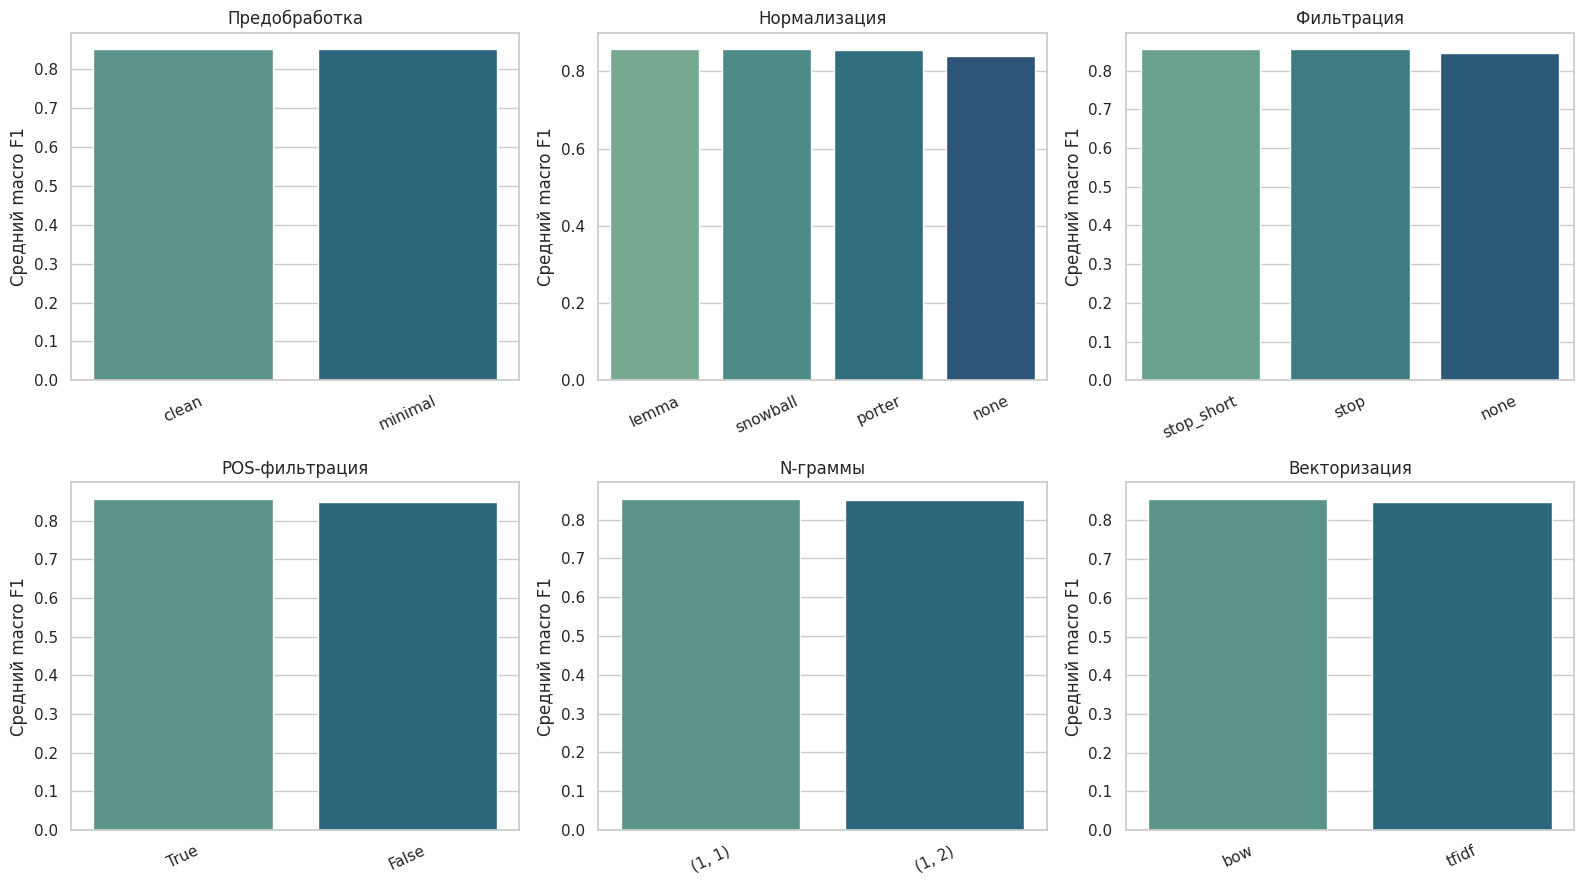

In [38]:

def summary_to_plot_df(summary_df: pd.DataFrame, index_name: str) -> pd.DataFrame:
    plot_df = summary_df.copy()
    plot_df[index_name] = [str(index_value) for index_value in plot_df.index]
    return plot_df.reset_index(drop=True)


fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plots = [
    (summary_to_plot_df(summary_by_preprocess, "preprocess_mode"), "preprocess_mode", axes[0, 0], "Предобработка"),
    (summary_to_plot_df(summary_by_normalization, "normalization_mode"), "normalization_mode", axes[0, 1], "Нормализация"),
    (summary_to_plot_df(summary_by_filter, "filter_mode"), "filter_mode", axes[0, 2], "Фильтрация"),
    (summary_to_plot_df(summary_by_pos, "use_pos_filter"), "use_pos_filter", axes[1, 0], "POS-фильтрация"),
    (summary_to_plot_df(summary_by_ngram, "ngram_range"), "ngram_range", axes[1, 1], "N-граммы"),
    (summary_to_plot_df(summary_by_vectorizer, "vectorizer"), "vectorizer", axes[1, 2], "Векторизация"),
]

for data, x_col, ax, title in plots:
    sns.barplot(data=data, x=x_col, y="mean", hue=x_col, dodge=False, legend=False, ax=ax, palette="crest")
    ax.set_title(title)
    ax.set_ylabel("Средний macro F1")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()



## Лучшая конфигурация и итоговая модель


In [39]:

best_config = results_df.iloc[0].to_dict()
best_config


{'filter_mode': 'none',
 'model_name': 'linearsvc',
 'ngram_range': (1, 1),
 'normalization_mode': 'lemma',
 'preprocess_mode': 'minimal',
 'use_pos_filter': True,
 'vectorizer': 'tfidf',
 'accuracy': 0.8942857142857142,
 'macro_f1': 0.8938684609163646,
 'vocab_size': 3466}

In [40]:

_, X_train_best, X_test_best = get_vectorized_split(best_config)

if best_config["model_name"] == "logreg":
    best_model = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )
else:
    best_model = LinearSVC(class_weight="balanced", random_state=RANDOM_STATE)

best_model.fit(X_train_best, y_train)
best_predictions = best_model.predict(X_test_best)

print(f"Accuracy: {accuracy_score(y_test, best_predictions):.4f}")
print(f"Macro F1: {f1_score(y_test, best_predictions, average='macro'):.4f}")
print()
print(classification_report(y_test, best_predictions))


Accuracy: 0.8943
Macro F1: 0.8939

              precision    recall  f1-score   support

          ai       0.88      0.95      0.91        88
   chemistry       0.94      0.90      0.92        87
      energy       0.88      0.90      0.89        88
   materials       0.89      0.83      0.86        87

    accuracy                           0.89       350
   macro avg       0.90      0.89      0.89       350
weighted avg       0.90      0.89      0.89       350



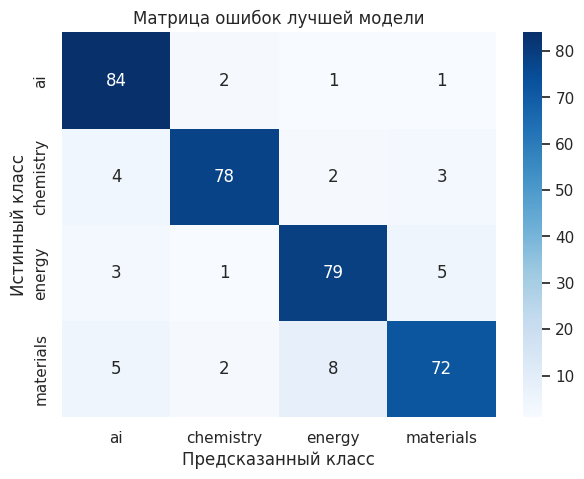

In [41]:

cm = confusion_matrix(y_test, best_predictions, labels=sorted(y_test.unique()))
cm_df = pd.DataFrame(cm, index=sorted(y_test.unique()), columns=sorted(y_test.unique()))

plt.figure(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Матрица ошибок лучшей модели")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()


In [42]:

best_vectorizer, _, _ = get_vectorized_split(best_config)
feature_names = np.array(best_vectorizer.get_feature_names_out())
classes = best_model.classes_

if hasattr(best_model, "coef_"):
    top_features = {}
    for class_index, class_name in enumerate(classes):
        class_coef = best_model.coef_[class_index]
        top_idx = np.argsort(class_coef)[-10:][::-1]
        top_features[class_name] = ", ".join(feature_names[top_idx])

    top_features_df = pd.DataFrame(
        {"class": list(top_features.keys()), "top_terms": list(top_features.values())}
    )
    display(top_features_df)
else:
    print("У выбранной модели нельзя интерпретировать веса признаков напрямую.")


,class,top_terms
0,ai,"prediction, algorithm, optimization, classification, learning, learn, neural, model, predict, code"
1,chemistry,"reaction, compound, chemical, molecule, synthesis, spectroscopy, chromatography, abstractthe, drug, antioxidant"
2,energy,"energy, solar, electrode, wave, velocity, battery, kinetic, activation, jet, photon"
3,materials,"material, film, carbon, alloy, composite, transport, nanoparticles, membrane, carbonate, hydrocarbon"



## Вывод


In [43]:

def format_group_winner(summary_df: pd.DataFrame) -> tuple[str, float]:
    summary_reset = summary_df.reset_index()
    winner_position = summary_reset["mean"].to_numpy().argmax()
    winner_label = summary_reset.iloc[winner_position, 0]
    winner_score = summary_reset.iloc[winner_position]["mean"]
    return str(winner_label), float(winner_score)

best_preprocess, best_preprocess_score = format_group_winner(summary_by_preprocess)
best_norm, best_norm_score = format_group_winner(summary_by_normalization)
best_filter, best_filter_score = format_group_winner(summary_by_filter)
best_pos, best_pos_score = format_group_winner(summary_by_pos)
best_ngram, best_ngram_score = format_group_winner(summary_by_ngram)
best_vectorizer_name, best_vectorizer_score = format_group_winner(summary_by_vectorizer)
best_model_name, best_model_score = format_group_winner(summary_by_model)

print("1. Задача анализа текста: многоклассовая классификация научных аннотаций по тематике.")
print(f"2. Лучшая средняя предобработка: {best_preprocess} (mean macro F1 = {best_preprocess_score:.4f}).")
print(f"3. Наиболее полезная нормализация: {best_norm} (mean macro F1 = {best_norm_score:.4f}).")
print(f"4. Наиболее полезная фильтрация: {best_filter} (mean macro F1 = {best_filter_score:.4f}).")
print(f"5. Влияние POS-фильтрации: лучший вариант = {best_pos} (mean macro F1 = {best_pos_score:.4f}).")
print(f"6. Влияние n-грамм: лучший диапазон = {best_ngram} (mean macro F1 = {best_ngram_score:.4f}).")
print(f"7. Лучшая векторизация: {best_vectorizer_name} (mean macro F1 = {best_vectorizer_score:.4f}).")
print(f"8. Лучшая модель: {best_model_name} (mean macro F1 = {best_model_score:.4f}).")
print(
    "9. Лучшая итоговая конфигурация:",
    {k: best_config[k] for k in [
        "preprocess_mode", "filter_mode", "normalization_mode", "use_pos_filter",
        "ngram_range", "vectorizer", "model_name"
    ]},
)
print(f"10. Итоговое качество лучшей модели: accuracy = {accuracy_score(y_test, best_predictions):.4f}, macro F1 = {f1_score(y_test, best_predictions, average='macro'):.4f}.")


1. Задача анализа текста: многоклассовая классификация научных аннотаций по тематике.
2. Лучшая средняя предобработка: clean (mean macro F1 = 0.8520).
3. Наиболее полезная нормализация: lemma (mean macro F1 = 0.8574).
4. Наиболее полезная фильтрация: stop_short (mean macro F1 = 0.8555).
5. Влияние POS-фильтрации: лучший вариант = True (mean macro F1 = 0.8560).
6. Влияние n-грамм: лучший диапазон = (1, 1) (mean macro F1 = 0.8532).
7. Лучшая векторизация: bow (mean macro F1 = 0.8557).
8. Лучшая модель: linearsvc (mean macro F1 = 0.8614).
9. Лучшая итоговая конфигурация: {'preprocess_mode': 'minimal', 'filter_mode': 'none', 'normalization_mode': 'lemma', 'use_pos_filter': True, 'ngram_range': (1, 1), 'vectorizer': 'tfidf', 'model_name': 'linearsvc'}
10. Итоговое качество лучшей модели: accuracy = 0.8943, macro F1 = 0.8939.
